# Part 1: Content-Based Filtering

# Task 1: Implementing TF-IDF Based Recommendation

In [93]:
import pandas as pd                                                                                                                                                                                                                                  
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

import warnings
warnings.filterwarnings('ignore')

# Notebook display settings
#pd.set_option('display.max_colwidth', 60)
#pd.set_option('display.max_columns', 10)

print('All libraries imported successfully')

All libraries imported successfully


## Loading the Dataset

In [94]:
movies  = pd.read_csv('movies.csv')   
ratings = pd.read_csv('ratings.csv')  
tags    = pd.read_csv('tags.csv')    
links   = pd.read_csv('links.csv')    

## Extracting the list of genres

In [95]:
#Creating a field "Movie Content" which is the combination of Genres and Tags for the corresponding movie 

# Splitting the genres with space instead of |
movies['genres_split'] = movies['genres'].str.replace('|', ' ', regex=False)

# Aggregating tags per movie
tag_aggregate = (
    tags.groupby('movieId')['tag']
    .apply(lambda t: ' '.join(t.dropna().astype(str).str.lower()))
    .reset_index()
    .rename(columns={'tag': 'tag_text'})
)

# Merging tags into movies
movies = movies.merge(tag_aggregate, on='movieId', how='left')

# Created this logic to compute average tag profile for each genre combination in order to generate valid recommendations for untagged movies
genre_tag_map = (
    movies[movies['tag_text'] != '']
    .groupby('genres')['tag_text']
    .apply(lambda x: ' '.join(x.dropna().astype(str)))
)

# Filling untagged movies with their genre's collective tags
def fill_tags(row):
    if row['tag_text'] == '' and row['genres'] in genre_tag_map:
        return genre_tag_map[row['genres']]
    return row['tag_text']

movies['tag_text'] = movies.apply(fill_tags, axis=1)
movies['content'] = movies['genres_split'] + ' ' + movies['tag_text']

## Computing TF-IDF Vectors

In [96]:
# ── Fit TF-IDF ─────────────────────────────────────────────────
movies['content'] = movies['content'].fillna('')
tfidf = TfidfVectorizer(
    stop_words='english',
    ngram_range=(1, 2),
    sublinear_tf=True
)

tfidf_matrix = tfidf.fit_transform(movies['content'])

print(f'TF-IDF matrix shape : {tfidf_matrix.shape}')
print(f'{tfidf_matrix.shape[0]:,} movies  ×  {tfidf_matrix.shape[1]:,} features')
print(f'Vocabulary size     : {len(tfidf.vocabulary_):,}')

TF-IDF matrix shape : (9742, 5487)
9,742 movies  ×  5,487 features
Vocabulary size     : 5,487


## Computing Cosine Similarity

In [97]:
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

print(f'Cosine similarity matrix : {cosine_sim.shape}')

Cosine similarity matrix : (9742, 9742)


In [98]:
movies['title_clean'] = movies['title'].str.strip()
title_to_idx = pd.Series(movies.index, index=movies['title_clean']).drop_duplicates()

## Recommendation Function

In [99]:
def get_recommendations(title: str, top_n: int = 5) -> pd.DataFrame:
   
    if title not in title_to_idx:
        matches = movies[movies['title_clean'].str.contains(title, case=False, na=False)]
        if matches.empty:
            print(f"'{title}' not found in the dataset.")
            return pd.DataFrame()
        title = matches.iloc[0]['title_clean']
        print(f"Movie '{title}' found in the dataset.")

    idx = title_to_idx[title]

    # Sorting by similarity
    similarity_scores = list(enumerate(cosine_sim[idx]))
    similarity_scores = sorted(similarity_scores, key=lambda x: x[1], reverse=True)
    similarity_scores = [(i, s) for i, s in similarity_scores if i != idx][:top_n]

    movie_indices = [i for i, _ in similarity_scores]
    scores        = [round(s, 4) for _, s in similarity_scores]

    result = movies.iloc[movie_indices][['title', 'genres']].copy()
    result.insert(0, 'rank', range(1, len(result) + 1))
    result['similarity_score'] = scores
    result = result.reset_index(drop=True)
    return result


## Testing the Recommender with Sample Queries

In [100]:
print('Top-5 Recommendations for "Pulp Fiction"')
get_recommendations('Pulp Fiction', top_n=5)

Top-5 Recommendations for "Pulp Fiction"
Movie 'Pulp Fiction (1994)' found in the dataset.


,rank,title,genres,similarity_score
0,1,"Big Lebowski, The (1998)",Comedy|Crime,0.1802
1,2,Reservoir Dogs (1992),Crime|Mystery|Thriller,0.1595
2,3,Kiss Kiss Bang Bang (2005),Comedy|Crime|Mystery|Thriller,0.1377
3,4,Man Bites Dog (C'est arrivé près de chez vous)...,Comedy|Crime|Drama|Thriller,0.1269
4,5,Django Unchained (2012),Action|Drama|Western,0.1215


In [101]:
print('Top-5 Recommendations for "Dark Knight":')
get_recommendations('Dark Knight', top_n=5)

Top-5 Recommendations for "Dark Knight":
Movie 'Dark Knight, The (2008)' found in the dataset.


,rank,title,genres,similarity_score
0,1,Batman Returns (1992),Action|Crime,0.3219
1,2,Batman (1989),Action|Crime|Thriller,0.2778
2,3,"History of Violence, A (2005)",Action|Crime|Drama|Thriller,0.2477
3,4,Munich (2005),Action|Crime|Drama|Thriller,0.2477
4,5,Face/Off (1997),Action|Crime|Drama|Thriller,0.2403


In [102]:
print('Top-5 Recommendations for "Inception":')
get_recommendations('Inception', top_n=5)

Top-5 Recommendations for "Inception":
Movie 'Inception (2010)' found in the dataset.


,rank,title,genres,similarity_score
0,1,Donnie Darko (2001),Drama|Mystery|Sci-Fi|Thriller,0.2871
1,2,Arrival (2016),Sci-Fi,0.2680
2,3,Eye in the Sky (2016),Drama|Thriller|War,0.2679
3,4,Doctor Strange (2016),Action|Adventure|Sci-Fi,0.2631
4,5,Primal Fear (1996),Crime|Drama|Mystery|Thriller,0.2482


In [103]:
print('Top-5 Recommendations for "Jumanji":')
get_recommendations('Jumanji', top_n=5)

Top-5 Recommendations for "Jumanji":
Movie 'Jumanji (1995)' found in the dataset.


,rank,title,genres,similarity_score
0,1,"Chronicles of Narnia: The Lion, the Witch and ...",Adventure|Children|Fantasy,0.2979
1,2,Harry Potter and the Chamber of Secrets (2002),Adventure|Fantasy,0.2928
2,3,"Chronicles of Narnia: Prince Caspian, The (2008)",Adventure|Children|Fantasy,0.2648
3,4,"Lord of the Rings: The Fellowship of the Ring,...",Adventure|Fantasy,0.2542
4,5,Night at the Museum (2006),Action|Comedy|Fantasy|IMAX,0.2470


In [104]:
print('Top-5 Recommendations for "Titanic":')
get_recommendations('Titanic', top_n=5)

Top-5 Recommendations for "Titanic":
Movie 'Titanic (1997)' found in the dataset.


,rank,title,genres,similarity_score
0,1,Random Harvest (1942),Drama|Romance,0.4840
1,2,Dangerous Liaisons (1988),Drama|Romance,0.2650
2,3,Brief Encounter (1946),Drama|Romance,0.2650
3,4,Shine (1996),Drama|Romance,0.2628
4,5,"Now, Voyager (1942)",Drama|Romance,0.2618


# Task 2: User-Profile-Based Content Recommender

In [105]:
#Creating a lookup for the movie id in TF-IDF matrix
movies_reset = movies.reset_index(drop=True)
movieid_to_idx = pd.Series(movies_reset.index, index=movies_reset['movieId']).drop_duplicates()

## Constructing User Profiles 

In [106]:
def build_user_profile(user_id: int) -> np.ndarray:
   
    user_ratings = ratings[ratings['userId'] == user_id][['movieId', 'rating']]

    if user_ratings.empty:
        return None
    user_ratings = user_ratings[user_ratings['movieId'].isin(movieid_to_idx.index)]
    if user_ratings.empty:
        return None
    profile      = np.zeros(tfidf_matrix.shape[1])
    total_weight = 0
    for _, row in user_ratings.iterrows():
        idx          = movieid_to_idx[row['movieId']]
        vector       = tfidf_matrix[idx].toarray().flatten()
        profile     += row['rating'] * vector
        total_weight += row['rating']

    if total_weight > 0:
        profile /= total_weight

    return profile

## Computing User Movie Similarity

In [107]:
def get_user_recommendations(user_id: int, top_n: int = 10) -> pd.DataFrame:
    profile = build_user_profile(user_id)

    if profile is None:
        print(f'User {user_id} not found or has no ratings.')
        return pd.DataFrame()

    # Computing cosine similarity between user and all movies
    profile_vec = profile.reshape(1, -1)
    sim_scores  = cosine_similarity(profile_vec, tfidf_matrix).flatten()

    # Exclude watched movies
    seen_movie_ids = set(ratings[ratings['userId'] == user_id]['movieId'])
    seen_indices   = set(movieid_to_idx[mid] for mid in seen_movie_ids if mid in movieid_to_idx.index)

    # Rank unwatched movies by similarity
    ranked = sorted(
        [(i, s) for i, s in enumerate(sim_scores) if i not in seen_indices],
        key=lambda x: x[1],
        reverse=True
    )[:top_n]

    movie_indices = [i for i, _ in ranked]
    scores        = [round(s, 4) for _, s in ranked]

    result = movies_reset.iloc[movie_indices][['movieId', 'title', 'genres']].copy()
    result.insert(0, 'rank', range(1, len(result) + 1))
    result['similarity_score'] = scores
    result = result.reset_index(drop=True)
    return result

## Returning the top-N most relevant movies for each user.

In [108]:
for uid in [1,100,200]:
    recs = get_user_recommendations(uid, top_n=5)
    n=5
    print('=' * 60)
    print(f'  Top-{n} Recommendations for User {uid}')
    print('=' * 60)
    if not recs.empty:
        print(recs.to_string(index=False))
    print()
    
for uid in [300,350,400]:  
    n=3
    recs = get_user_recommendations(uid, top_n=3)
    print('=' * 60)
    print(f'  Top-{n} Recommendations for User {uid}')
    print('=' * 60)
    if not recs.empty:
        print(recs.to_string(index=False))
    print()

  Top-5 Recommendations for User 1
 rank  movieId                                                     title                                             genres  similarity_score
    1     6350 Laputa: Castle in the Sky (Tenkû no shiro Rapyuta) (1986) Action|Adventure|Animation|Children|Fantasy|Sci-Fi            0.4963
    2     5349                                         Spider-Man (2002)                   Action|Adventure|Sci-Fi|Thriller            0.4623
    3     2642                                       Superman III (1983)                            Action|Adventure|Sci-Fi            0.4566
    4    91500                                   The Hunger Games (2012)             Action|Adventure|Drama|Sci-Fi|Thriller            0.4545
    5     1544                     Lost World: Jurassic Park, The (1997)                   Action|Adventure|Sci-Fi|Thriller            0.4111

  Top-5 Recommendations for User 100
 rank  movieId                                       title               ge

## Evaluating Personalization

In [109]:
def evaluate_user(user_id: int, k: int = 10, threshold: float = 4.0):
    
    # Movies the user actually rated highly (ground trutg
    user_ratings = ratings[ratings['userId'] == user_id]
    liked = set(user_ratings[user_ratings['rating'] >= threshold]['movieId'])
    
    if not liked:
        return None

    # Top-n recommended movies
    profile    = build_user_profile(user_id)
    sim_scores = cosine_similarity(profile.reshape(1, -1), tfidf_matrix).flatten()
    
    ranked          = sorted(enumerate(sim_scores), key=lambda x: x[1], reverse=True)[:k]
    recommended_ids = set(movies_reset.iloc[i]['movieId'] for i, _ in ranked)

    # Comparing against the ground truth
    hits      = len(recommended_ids & liked)
    precision = hits / k
    recall    = hits / len(liked)

    return {
        'user_id'     : user_id,
        'precision@K' : round(precision, 4),
        'recall@K'    : round(recall, 4),
        'hits'        : hits,
        'liked_movies': len(liked)
    }


sample_users = ratings['userId'].drop_duplicates().sample(20, random_state=42).tolist()
results      = [evaluate_user(uid, k=10) for uid in sample_users]
results      = [r for r in results if r is not None]
eval_df      = pd.DataFrame(results)

print(eval_df.to_string(index=False))
print()
print(f"Mean Precision@10 : {eval_df['precision@K'].mean():.4f}")
print(f"Mean Recall@10    : {eval_df['recall@K'].mean():.4f}")

 user_id  precision@K  recall@K  hits  liked_movies
      82          0.2    0.0250     2            80
     219          0.2    0.0114     2           175
      56          0.2    0.0690     2            29
     599          0.3    0.0158     3           190
     265          0.4    0.0533     4            75
     156          0.1    0.0046     1           216
     483          0.4    0.0106     4           376
     322          0.0    0.0000     0            39
     581          0.6    0.1714     6            35
     292          0.6    0.0319     6           188
     239          0.5    0.0251     5           199
     251          0.5    0.2273     5            22
     197          0.4    0.1905     4            21
     395          0.0    0.0000     0            14
     291          0.6    0.2222     6            27
     321          0.5    0.1923     5            26
     547          0.5    0.3333     5            15
     525          0.1    0.0047     1           211
      11    

# Part 2: Collaborative Filtering

# Task 3: User-Based Collaborative Filtering

## Populating a user-movie rating matrix from the dataset

In [110]:

rating_matrix = ratings.pivot_table(index='userId', columns='movieId', values='rating')

# Calculating pairwise similarity between users using Pearson correlation as user ratings have different biases
rating_matrix_filled = rating_matrix.fillna(0)
user_sim_matrix = np.corrcoef(rating_matrix_filled.values)
user_sim_df = pd.DataFrame(user_sim_matrix,
                            index=rating_matrix.index,
                            columns=rating_matrix.index)

user_sim_df = user_sim_df.fillna(0)

## Predict ratings for a given user using weighted average of neighbors

In [111]:
def predict_rating(user_id: int, movie_id: int, k: int = 20) -> float:
    if movie_id not in rating_matrix.columns:
        return np.nan

    # Getting similarity scores for user vs others
    sim_scores = user_sim_df[user_id].drop(user_id)

    rated_users = rating_matrix[movie_id].dropna().index
    sim_scores  = sim_scores[sim_scores.index.isin(rated_users)]

    sim_scores = sim_scores[sim_scores > 0]
    if sim_scores.empty:
        return rating_matrix[movie_id].mean()

    # Top-K most similar users
    top_k = sim_scores.nlargest(k)

    # Weighted average of their ratings
    neighbour_ratings = rating_matrix.loc[top_k.index, movie_id]
    weights           = top_k.values
    weight_sum        = np.abs(weights).sum()

    if weight_sum == 0:
        return rating_matrix[movie_id].mean()

    predicted = np.dot(weights, neighbour_ratings.values) / weight_sum
    return float(np.clip(predicted, 0.5, 5.0))   

print(f'Predicted rating for User 1, Movie 31: {predict_rating(1, 31):.2f}')

Predicted rating for User 1, Movie 31: 2.94


## Implement a recommendation function based on predicted ratings

In [112]:
def recommend_userbased(user_id: int, top_n: int = 10, k: int = 20) -> pd.DataFrame:
    # Movies already rated by user
    rated_movies = set(rating_matrix.loc[user_id].dropna().index)

    # Predict ratings for all unrated movies
    unrated = [mid for mid in rating_matrix.columns if mid not in rated_movies]
    predictions = [(mid, predict_rating(user_id, mid, k)) for mid in unrated]
    predictions = sorted(predictions, key=lambda x: x[1], reverse=True)[:top_n]

    movie_ids = [p[0] for p in predictions]
    pred_ratings = [round(p[1], 3) for p in predictions]

    result = movies[movies['movieId'].isin(movie_ids)][['movieId','title','genres']].copy()
    result = result.set_index('movieId').loc[movie_ids].reset_index()
    result.insert(0, 'rank', range(1, len(result)+1))
    result['predicted_rating'] = pred_ratings
    return result

# Test with sample users
for uid in [1, 25, 30]:
    print(f'\n{"="*55}')
    print(f'  Top-5 highest rated movies for User {uid}')
    print(f'={"="*54}')
    print(recommend_userbased(uid, top_n=5).to_string(index=False))


  Top-5 highest rated movies for User 1
 rank  movieId                                             title          genres  predicted_rating
    1       53                                   Lamerica (1994) Adventure|Drama               5.0
    2       99              Heidi Fleiss: Hollywood Madam (1995)     Documentary               5.0
    3      148                  Awfully Big Adventure, An (1995)           Drama               5.0
    4      467                            Live Nude Girls (1995)          Comedy               5.0
    5      495 In the Realm of the Senses (Ai no corrida) (1976)           Drama               5.0

  Top-5 highest rated movies for User 25
 rank  movieId                                             title          genres  predicted_rating
    1       53                                   Lamerica (1994) Adventure|Drama               5.0
    2       99              Heidi Fleiss: Hollywood Madam (1995)     Documentary               5.0
    3      148            

## Evaluate the system with RMSE (Root Mean Squared Error), Precision@K, and Recall@K

In [113]:
from sklearn.metrics import mean_squared_error

def evaluate_userbased(sample_size: int = 100, k_neighbours: int = 20, top_k: int = 10, threshold: float = 4.0):
    sample = ratings.sample(n=sample_size, random_state=42)
    actuals, predicted = [], []
    for _, row in sample.iterrows():
        pred = predict_rating(int(row['userId']), int(row['movieId']), k_neighbours)
        if not np.isnan(pred):
            actuals.append(row['rating'])
            predicted.append(pred)
    rmse = np.sqrt(mean_squared_error(actuals, predicted))


    precisions, recalls = [], []
    for uid in ratings['userId'].drop_duplicates().sample(20, random_state=42):
        
        # Ground truth: movies user actually rated highly
        user_liked = set(ratings[(ratings['userId']==uid) & (ratings['rating']>=threshold)]['movieId'])
        if not user_liked:
            continue

        # Predicting ratings for ALL movies including watched ones
        all_movies = rating_matrix.columns.tolist()
        predictions = [(mid, predict_rating(uid, mid, k_neighbours)) for mid in all_movies]
        predictions = [(mid, r) for mid, r in predictions if not np.isnan(r)]
        predictions = sorted(predictions, key=lambda x: x[1], reverse=True)[:top_k]
        recommended_ids = set(mid for mid, _ in predictions)

        hits = len(recommended_ids & user_liked)
        precisions.append(hits / top_k)
        recalls.append(hits / len(user_liked))

    print(f'Evaluation (K={k_neighbours}, top_k={top_k}):')
    print(f'  RMSE          : {rmse:.4f}')
    print(f'  Precision@{top_k}  : {np.mean(precisions):.4f}')
    print(f'  Recall@{top_k}     : {np.mean(recalls):.4f}')
    return rmse, np.mean(precisions), np.mean(recalls)

rmse_ub, prec_ub, rec_ub = evaluate_userbased()

Evaluation (K=20, top_k=10):
  RMSE          : 0.8923
  Precision@10  : 0.0000
  Recall@10     : 0.0000


## Testing with different values of K (number of similar users) to see how recommendation quality changes

Testing K=10...
Evaluation (K=10, top_k=10):
  RMSE          : 0.8801
  Precision@10  : 0.0050
  Recall@10     : 0.0002
Testing K=20...
Evaluation (K=20, top_k=10):
  RMSE          : 0.8973
  Precision@10  : 0.0000
  Recall@10     : 0.0000
Testing K=30...
Evaluation (K=30, top_k=10):
  RMSE          : 0.9071
  Precision@10  : 0.0000
  Recall@10     : 0.0000
Testing K=40...
Evaluation (K=40, top_k=10):
  RMSE          : 0.9041
  Precision@10  : 0.0000
  Recall@10     : 0.0000

Effect of K on recommendation quality:
 K   RMSE  Precision@10  Recall@10
10 0.8801         0.005     0.0002
20 0.8973         0.000     0.0000
30 0.9071         0.000     0.0000
40 0.9041         0.000     0.0000


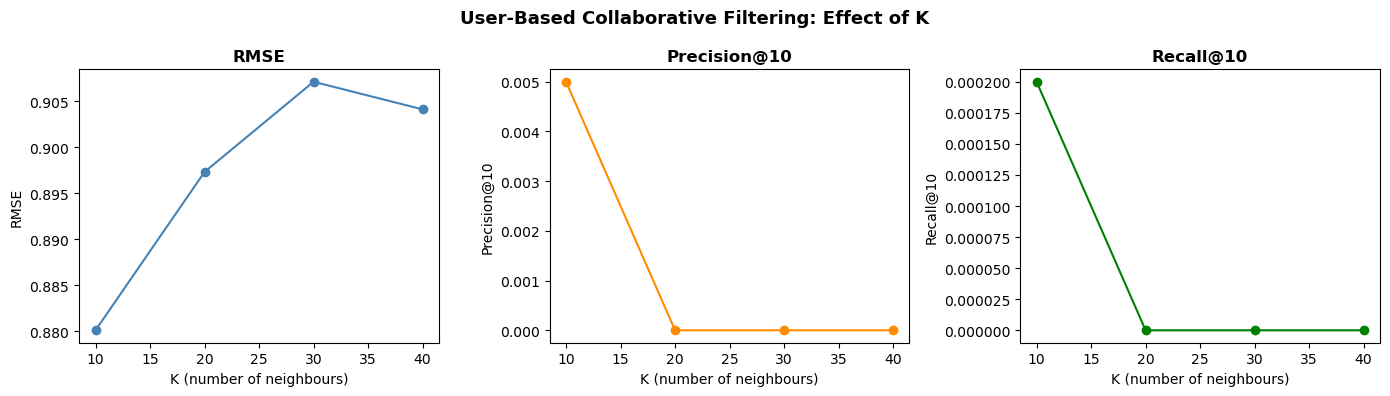

In [114]:
k_values = [10, 20, 30, 40]
results_k = []

for k in k_values:
    print(f'Testing K={k}...')
    rmse, prec, rec = evaluate_userbased(sample_size=50, k_neighbours=k, top_k=10)
    results_k.append({'K': k, 'RMSE': round(rmse,4), 'Precision@10': round(prec,4), 'Recall@10': round(rec,4)})

k_df = pd.DataFrame(results_k)
print('\nEffect of K on recommendation quality:')
print(k_df.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col, color in zip(axes, ['RMSE','Precision@10','Recall@10'], ['steelblue','darkorange','green']):
    ax.plot(k_df['K'], k_df[col], marker='o', color=color)
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel('K (number of neighbours)')
    ax.set_ylabel(col)
plt.suptitle('User-Based Collaborative Filtering: Effect of K', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Task 4: Item-Based Collaborative Filtering

## Computing item-item similarity using cosine similarity

In [115]:

item_matrix = rating_matrix.T.fillna(0)
item_sim_matrix = cosine_similarity(item_matrix)
item_sim_df = pd.DataFrame(item_sim_matrix,
                            index=rating_matrix.columns,
                            columns=rating_matrix.columns)

## Predict ratings for a given user based on similar items

In [116]:

def predict_rating_itembased(user_id: int, movie_id: int, k: int = 20) -> float:

    if movie_id not in item_sim_df.index:
        return np.nan

    # Items already rated by user
    user_rated = rating_matrix.loc[user_id].dropna()
    if user_rated.empty:
        return np.nan

    # Finding similar items
    sim_scores = item_sim_df[movie_id][user_rated.index].dropna()
    sim_scores = sim_scores.nlargest(k)

    if sim_scores.empty:
        return np.nan

    # Weighted average
    weights  = sim_scores.values
    r_values = user_rated[sim_scores.index].values
    weight_sum = np.abs(weights).sum()

    if weight_sum == 0:
        return np.nan

    predicted = np.dot(weights, r_values) / weight_sum
    return float(np.clip(predicted, 0.5, 5.0))

print(f'Predicted rating for User 10, Movie 100: {predict_rating_itembased(10, 100):.2f}')

Predicted rating for User 10, Movie 100: 3.11


## Generate top-N movie recommendations for a user

In [117]:
def recommend_itembased(user_id: int, top_n: int = 10, k: int = 20) -> pd.DataFrame:

    rated_movies = set(rating_matrix.loc[user_id].dropna().index)
    unrated      = [mid for mid in rating_matrix.columns if mid not in rated_movies]

    predictions = [(mid, predict_rating_itembased(user_id, mid, k)) for mid in unrated]
    predictions = [(mid, r) for mid, r in predictions if not np.isnan(r)]
    predictions = sorted(predictions, key=lambda x: x[1], reverse=True)[:top_n]

    movie_ids    = [p[0] for p in predictions]
    pred_ratings = [round(p[1], 3) for p in predictions]

    result = movies[movies['movieId'].isin(movie_ids)][['movieId','title','genres']].copy()
    result = result.set_index('movieId').loc[movie_ids].reset_index()
    result.insert(0, 'rank', range(1, len(result)+1))
    result['predicted_rating'] = pred_ratings
    return result


for uid in [1, 10, 20]:
    print(f'\n{"="*55}')
    print(f'  Top-5 Movie Recommendations for User {uid}')
    print(f'={"="*55}')
    print(recommend_itembased(uid, top_n=5).to_string(index=False))


  Top-5 Movie Recommendations for User 1
 rank  movieId                                             title               genres  predicted_rating
    1     1140 Entertaining Angels: The Dorothy Day Story (1996)                Drama               5.0
    2     1519                             Broken English (1996)                Drama               5.0
    3     2896                              Alvarez Kelly (1966)              Western               5.0
    4     3106                      Come See the Paradise (1990)        Drama|Romance               5.0
    5     3899                                     Circus (2000) Crime|Drama|Thriller               5.0

  Top-5 Movie Recommendations for User 10
 rank  movieId                     title                           genres  predicted_rating
    1     6158 Jungle Book 2, The (2003)               Animation|Children             4.380
    2    63239         Cinderella (1997) Children|Fantasy|Musical|Romance             4.380
    3     4284 

## Evaluate the system and compare the recommendations with user-based CF to analyze differences in output

In [118]:
def evaluate_itembased(sample_size=100, k_neighbours=20, top_k=10, threshold=4.0):
    
   
    sample = ratings.sample(n=sample_size, random_state=42)
    actuals, predicted = [], []
    for _, row in sample.iterrows():
        pred = predict_rating_itembased(int(row['userId']), int(row['movieId']), k_neighbours)
        if pred and not np.isnan(pred):
            actuals.append(row['rating'])
            predicted.append(pred)
    rmse = np.sqrt(mean_squared_error(actuals, predicted))

    
    precisions, recalls = [], []
    for uid in ratings['userId'].drop_duplicates().sample(20, random_state=42):

   
        user_liked = set(ratings[(ratings['userId']==uid) & (ratings['rating']>=threshold)]['movieId'])
        if not user_liked:
            continue

        
        all_movies  = rating_matrix.columns.tolist()
        predictions = [(mid, predict_rating_itembased(uid, mid, k_neighbours)) for mid in all_movies]
        predictions = [(mid, r) for mid, r in predictions if r and not np.isnan(r)]
        predictions = sorted(predictions, key=lambda x: x[1], reverse=True)[:top_k]

        if not predictions:
            continue

        recommended_ids = set(mid for mid, _ in predictions)
        hits = len(recommended_ids & user_liked)
        precisions.append(hits / top_k)
        recalls.append(hits / len(user_liked))

    print(f'Item-Based CF Evaluation (K={k_neighbours}, top_k={top_k}):')
    print(f'  RMSE          : {rmse:.4f}')
    print(f'  Precision@{top_k}  : {np.mean(precisions):.4f}')
    print(f'  Recall@{top_k}     : {np.mean(recalls):.4f}')
    return rmse, np.mean(precisions), np.mean(recalls)

rmse_ib, prec_ib, rec_ib = evaluate_itembased()

Item-Based CF Evaluation (K=20, top_k=10):
  RMSE          : 0.8162
  Precision@10  : 0.2000
  Recall@10     : 0.0240


In [119]:
print('\nComparison: User-Based CF vs Item-Based CF')
comp = pd.DataFrame({
    'Method'      : ['User-Based CF', 'Item-Based CF'],
    'RMSE'        : [round(rmse_ub,4), round(rmse_ib,4)],
    'Precision@10': [round(prec_ub,4), round(prec_ib,4)],
    'Recall@10'   : [round(rec_ub,4),  round(rec_ib,4)]
})
print(comp.to_string(index=False))


Comparison: User-Based CF vs Item-Based CF
       Method   RMSE  Precision@10  Recall@10
User-Based CF 0.8923           0.0      0.000
Item-Based CF 0.8162           0.2      0.024


## Do you think item based CF may be faster or more memory-efficient than user based CF in the real world? Why?

Yes, item based CF is faster and more memory efficient because of the following:
1. Number of Items(movies) grows slowly whereas the number of users grows rapidly and continuously.
2. Item item similarity matrix can be computed and reused for all users whereas user user similarity matrix need to be recomputed whenever a new user joins.
3. The number of users are massive compared to the number of items(movies). Therefore, items win in memory efficiency.
4. Item based CF looks up the pre-computed similarities and looks up the items the users have rated whereas user based CF requires scanning all the users.
5. Based on the results, it is evident that item based similarities offer stable, meaningful and reliable results compared to user based similarities in sparse data.

# Part 3: Matrix Factorization for Recommender Systems

# Task 5: Implementing SVD for Recommendations

In [120]:
## Prepare the user-item matrix for factorization

In [121]:
user_mean = rating_matrix.mean(axis=1)
rating_matrix_filled_svd = rating_matrix.apply(lambda row: row.fillna(row.mean()), axis=1)
rating_matrix_filled_svd = rating_matrix_filled_svd.fillna(0)   # users with no ratings

R = rating_matrix_filled_svd.values

In [122]:
## Apply Singular Value Decomposition (SVD) using scipy or numpy functions

U  shape : (610, 610)
Σ  shape : (610,)
Vt shape : (610, 9724)


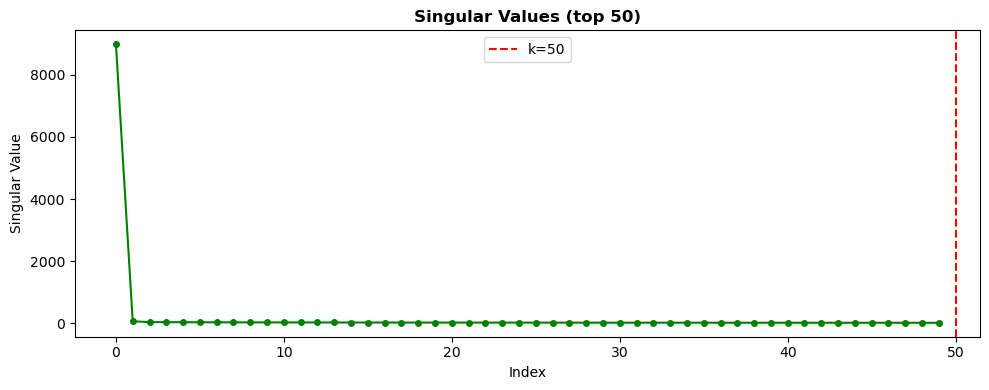

In [123]:
from numpy.linalg import svd

U,sigma,Vt = svd(R, full_matrices=False)

print(f'U  shape : {U.shape}')
print(f'Σ  shape : {sigma.shape}')
print(f'Vt shape : {Vt.shape}')

plt.figure(figsize=(10, 4))
plt.plot(sigma[:50], marker='o', markersize=4, color='green')
plt.title('Singular Values (top 50)', fontweight='bold')
plt.xlabel('Index')
plt.ylabel('Singular Value')
plt.axvline(x=50, color='red', linestyle='--', label='k=50')
plt.legend()
plt.tight_layout()
plt.show()

## Predict missing ratings

In [124]:

k = 50 

U_k     = U[:, :k]
sigma_k = np.diag(sigma[:k])
Vt_k    = Vt[:k, :]

R_hat = np.dot(U_k, np.dot(sigma_k, Vt_k))

# Clip to valid rating range (1-5)
R_hat = np.clip(R_hat, 0.5, 5.0)

R_hat_df = pd.DataFrame(R_hat,
                         index=rating_matrix.index,
                         columns=rating_matrix.columns)

print(f'Reconstructed matrix shape: {R_hat_df.shape}')
print(f'Sample predicted ratings (User 1, first 5 movies):')
print(R_hat_df.iloc[0, :5].round(2))

Reconstructed matrix shape: (610, 9724)
Sample predicted ratings (User 1, first 5 movies):
movieId
1    4.32
2    4.29
3    4.37
4    4.37
5    4.33
Name: 1, dtype: float64


In [125]:
## Use the reconstructed ratings to suggest top-N recommended movies for a given user

In [126]:
def recommend_svd(user_id: int, top_n: int = 10) -> pd.DataFrame:
    if user_id not in R_hat_df.index:
        print(f'User {user_id} not found.')
        return pd.DataFrame()

    rated_movies = set(rating_matrix.loc[user_id].dropna().index)

    # Get predicted ratings for unrated movies
    user_preds = R_hat_df.loc[user_id]
    user_preds = user_preds[~user_preds.index.isin(rated_movies)]
    top_movies = user_preds.nlargest(top_n)

    result = movies[movies['movieId'].isin(top_movies.index)][['movieId','title','genres']].copy()
    result = result.set_index('movieId').loc[top_movies.index].reset_index()
    result.insert(0, 'rank', range(1, len(result)+1))
    result['predicted_rating'] = top_movies.values.round(3)
    return result


for uid in [1, 50, 100]:
    print(f'\n{"="*55}')
    print(f'  Top-5 SVD Recommendations for User {uid}')
    print(f'={"="*54}')
    print(recommend_svd(uid, top_n=5).to_string(index=False))


  Top-5 SVD Recommendations for User 1
 rank  movieId                             title                 genres  predicted_rating
    1      541               Blade Runner (1982) Action|Sci-Fi|Thriller             4.716
    2      344 Ace Ventura: Pet Detective (1994)                 Comedy             4.661
    3     1246         Dead Poets Society (1989)                  Drama             4.629
    4     2804         Christmas Story, A (1983)        Children|Comedy             4.602
    5     4011                     Snatch (2000)  Comedy|Crime|Thriller             4.598

  Top-5 SVD Recommendations for User 50
 rank  movieId                                  title                 genres  predicted_rating
    1     2858                 American Beauty (1999)          Drama|Romance             3.228
    2     1193 One Flew Over the Cuckoo's Nest (1975)                  Drama             3.217
    3     1089                  Reservoir Dogs (1992) Crime|Mystery|Thriller             3.211

In [127]:
## Evaluate SVD-based recommendations and compare with item-based and user-based CF.

In [128]:
def evaluate_svd(sample_size=500, top_k=10, threshold=4.0):
    sample = ratings.sample(n=sample_size, random_state=42)
    actuals, predicted = [], []

    for _, row in sample.iterrows():
        uid, mid = int(row['userId']), int(row['movieId'])
        if uid in R_hat_df.index and mid in R_hat_df.columns:
            actuals.append(row['rating'])
            predicted.append(R_hat_df.loc[uid, mid])

    rmse = np.sqrt(mean_squared_error(actuals, predicted))

    precisions, recalls = [], []
    for uid in ratings['userId'].drop_duplicates().sample(20, random_state=42):
        user_liked = set(ratings[(ratings['userId']==uid) & (ratings['rating']>=threshold)]['movieId'])
        if not user_liked: continue
        recs = recommend_svd(uid, top_n=top_k)
        if recs.empty: continue
        hits = len(set(recs['movieId']) & user_liked)
        precisions.append(hits / top_k)
        recalls.append(hits / len(user_liked))

    print(f'SVD Evaluation (k={k}, top_k={top_k}):')
    print(f'  RMSE          : {rmse:.4f}')
    print(f'  Precision@{top_k}  : {np.mean(precisions):.4f}')
    print(f'  Recall@{top_k}     : {np.mean(recalls):.4f}')
    return rmse, np.mean(precisions), np.mean(recalls)

rmse_svd, prec_svd, rec_svd = evaluate_svd()


print('\nComparison: User-CF vs Item-CF vs SVD')
final_comp = pd.DataFrame({
    'Method'      : ['User-Based CF', 'Item-Based CF', 'SVD'],
    'RMSE'        : [round(rmse_ub,4), round(rmse_ib,4), round(rmse_svd,4)],
    'Precision@10': [round(prec_ub,4), round(prec_ib,4), round(prec_svd,4)],
    'Recall@10'   : [round(rec_ub,4),  round(rec_ib,4),  round(rec_svd,4)]
})
print(final_comp.to_string(index=False))

SVD Evaluation (k=50, top_k=10):
  RMSE          : 0.6512
  Precision@10  : 0.0000
  Recall@10     : 0.0000

Comparison: User-CF vs Item-CF vs SVD
       Method   RMSE  Precision@10  Recall@10
User-Based CF 0.8923           0.0      0.000
Item-Based CF 0.8162           0.2      0.024
          SVD 0.6512           0.0      0.000


# Task 6: Implementing Matrix Factorization with the Surprise Library

## Load the dataset into the surprise framework. Split it into train-test sets

In [129]:
pip install scikit-surprise

In [130]:
from surprise import SVD, Dataset, Reader, accuracy
from surprise.model_selection import cross_validate, train_test_split as sur_split
from surprise import accuracy as sur_accuracy

reader  = Reader(rating_scale=(0.5, 5.0))
data    = Dataset.load_from_df(ratings[['userId','movieId','rating']], reader)
trainset, testset = sur_split(data, test_size=0.2, random_state=42)

## Train an SVD model using surprise and tune the hyperparameters

In [131]:
svd_model = SVD(n_factors=100, n_epochs=20, lr_all=0.005, reg_all=0.02, random_state=42)
svd_model.fit(trainset)
print('Surprise SVD model trained successfully!')

Surprise SVD model trained successfully!


## Evaluate model performance with RMSE, Precision@K, and Recall@K

In [132]:
predictions = svd_model.test(testset)
rmse_surprise = sur_accuracy.rmse(predictions, verbose=False)
mae_surprise  = sur_accuracy.mae(predictions,  verbose=False)

print(f'Surprise SVD — RMSE : {rmse_surprise:.4f}')
print(f'Surprise SVD — MAE  : {mae_surprise:.4f}')

from collections import defaultdict

def precision_recall_surprise(predictions, k=10, threshold=4.0):
    user_est_true = defaultdict(list)
    for uid, _, true_r, est, _ in predictions:
        user_est_true[uid].append((est, true_r))

    precisions, recalls = {}, {}
    for uid, user_ratings_list in user_est_true.items():
        user_ratings_list.sort(key=lambda x: x[0], reverse=True)
        n_rel   = sum(1 for (_, true_r) in user_ratings_list if true_r >= threshold)
        n_rec_k = sum(1 for (est, _)    in user_ratings_list[:k] if est >= threshold)
        n_rel_k = sum(1 for (est, true_r) in user_ratings_list[:k] if est >= threshold and true_r >= threshold)
        precisions[uid] = n_rec_k / k if k != 0 else 0
        recalls[uid]    = n_rel_k / n_rel if n_rel != 0 else 0

    return np.mean(list(precisions.values())), np.mean(list(recalls.values()))

prec_sur, rec_sur = precision_recall_surprise(predictions)
print(f'Surprise SVD — Precision@10 : {prec_sur:.4f}')
print(f'Surprise SVD — Recall@10    : {rec_sur:.4f}')

Surprise SVD — RMSE : 0.8807
Surprise SVD — MAE  : 0.6766
Surprise SVD — Precision@10 : 0.4034
Surprise SVD — Recall@10    : 0.2794


## Compare Surprise’s SVD implementation vs. the SVD implementation from task 5.

In [133]:
print('\nSurprise SVD vs Manual SVD')
compare_svd = pd.DataFrame({
    'Method'      : ['Manual SVD (numpy)', 'Surprise SVD'],
    'RMSE'        : [round(rmse_svd, 4),    round(rmse_surprise, 4)],
    'Precision@10': [round(prec_svd, 4),    round(prec_sur, 4)],
    'Recall@10'   : [round(rec_svd, 4),     round(rec_sur, 4)]
})
print(compare_svd.to_string(index=False))


Surprise SVD vs Manual SVD
            Method   RMSE  Precision@10  Recall@10
Manual SVD (numpy) 0.6512        0.0000     0.0000
      Surprise SVD 0.8807        0.4034     0.2794


## Comparison between Surprise's SVD Implementation & SVD Implementation 

1. Surprise SVD is efficient as it uses Stochastic Gradient Descent for optimization
2. Classic SVD fills missing values before factorization which can introduce bias whereas Surprise SVD learns from observed ratings and avoids the bias
3. Surprise SVD is faster and scales better for large datasets 

# Part 4: Hybrid Recommendation Model

# Task 7: Implementing a Hybrid Recommendation Model

## Implement a meta-learning strategy

In [134]:
import pandas as pd
import numpy as np
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split as skl_split


print('Building meta-model feature matrix!')
sample_ratings = ratings.sample(n=2000, random_state=42).copy()

cbf_scores, cf_scores, movie_pop, user_bias_col = [], [], [], []

movie_avg = ratings.groupby('movieId')['rating'].mean()
user_avg  = ratings.groupby('userId')['rating'].mean()

for _, row in sample_ratings.iterrows():
    uid = int(row['userId'])
    mid = int(row['movieId'])

    # CBF score
    profile = build_user_profile(uid)
    if profile is not None and mid in movieid_to_idx.index:
        idx = movieid_to_idx[mid]
        vec = tfidf_matrix[idx].toarray().flatten()
        cbf = float(np.dot(profile, vec) / (np.linalg.norm(profile) * np.linalg.norm(vec) + 1e-9))
    else:
        cbf = 0.0

    cf = R_hat_df.loc[uid, mid] if (uid in R_hat_df.index and mid in R_hat_df.columns) else 3.0

    cbf_scores.append(cbf)
    cf_scores.append(float(cf))
    movie_pop.append(movie_avg.get(mid, 3.0))
    user_bias_col.append(user_avg.get(uid, 3.0))

sample_ratings['cbf_score']   = cbf_scores
sample_ratings['cf_score']    = cf_scores
sample_ratings['movie_pop']   = movie_pop
sample_ratings['user_bias']   = user_bias_col

print('Feature matrix built')
print(sample_ratings[['userId','movieId','rating','cbf_score','cf_score','movie_pop','user_bias']].head())

Building meta-model feature matrix!
Feature matrix built
       userId  movieId  rating  cbf_score  cf_score  movie_pop  user_bias
67037     432    77866     4.5   0.000000  3.655457   3.166667   3.646154
42175     288      474     3.0   0.136148  2.931847   3.692857   3.145972
93850     599     4351     3.0   0.000000  3.010007   3.250000   2.642050
6187       42     2987     4.0   0.240881  4.359693   3.572165   3.565909
12229      75     1610     4.0   0.287081  3.400356   3.872222   3.231884


## Use historical user ratings as ground truth and train a meta-model to predict how a user will rate a movie

In [135]:

features = ['cbf_score', 'cf_score', 'movie_pop', 'user_bias']
X = sample_ratings[features].values
y = sample_ratings['rating'].values

X_train, X_test, y_train, y_test = skl_split(X, y, test_size=0.2, random_state=42)

meta_model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1,
                                        max_depth=3, random_state=42)
meta_model.fit(X_train, y_train)
print('Meta-model trained successfully ')

imp_df = pd.DataFrame({'feature': features, 'importance': meta_model.feature_importances_})
print('\nFeature importances:')
print(imp_df.sort_values('importance', ascending=False).to_string(index=False))

Meta-model trained successfully 

Feature importances:
  feature  importance
 cf_score    0.864116
movie_pop    0.062906
user_bias    0.051218
cbf_score    0.021760


## Evaluate the hybrid model using RMSE, Precision@K, and Recall@K.

In [136]:

y_pred = np.clip(meta_model.predict(X_test), 0.5, 5.0)
rmse_hybrid = np.sqrt(mean_squared_error(y_test, y_pred))

threshold = 4.0
top_k     = 10
test_df   = sample_ratings.iloc[len(X_train):]

precisions, recalls = [], []
for uid in test_df['userId'].unique()[:20]:
    user_liked = set(ratings[(ratings['userId']==uid) & (ratings['rating']>=threshold)]['movieId'])
    if not user_liked: continue
    user_test = test_df[test_df['userId']==uid]
    if user_test.empty: continue
    user_test = user_test.copy()
    user_test['hybrid_pred'] = np.clip(meta_model.predict(user_test[features]), 0.5, 5.0)
    top_recs = set(user_test.nlargest(top_k, 'hybrid_pred')['movieId'])
    hits = len(top_recs & user_liked)
    precisions.append(hits / top_k)
    recalls.append(hits / len(user_liked))

print('Hybrid Model Evaluation')
print(f'  RMSE          : {rmse_hybrid:.4f}')
print(f'  Precision@10  : {np.mean(precisions):.4f}')
print(f'  Recall@10     : {np.mean(recalls):.4f}')

Hybrid Model Evaluation
  RMSE          : 0.5859
  Precision@10  : 0.1350
  Recall@10     : 0.0164


## Compare against CF and CBF recommender systems

In [137]:
#Calculating values for CBF
cbf_actuals, cbf_predicted = [], []
cbf_precisions, cbf_recalls = [], []

sample_uids = ratings['userId'].drop_duplicates().sample(20, random_state=42)

for uid in sample_uids:
    uid = int(uid)
    user_ratings_all = ratings[ratings['userId'] == uid]
    user_liked       = set(user_ratings_all[user_ratings_all['rating'] >= 4.0]['movieId'])

    if not user_liked:
        continue

    profile = build_user_profile(uid)
    if profile is None:
        continue
    for _, row in user_ratings_all.iterrows():
        mid = int(row['movieId'])
        if mid not in movieid_to_idx.index:
            continue
        idx  = movieid_to_idx[mid]
        m_vec = tfidf_matrix[idx].toarray().flatten()
        norm  = np.linalg.norm(profile) * np.linalg.norm(m_vec)
        if norm == 0:
            continue
        sim  = np.dot(profile, m_vec) / norm
        pred = 0.5 + sim * 4.5         # scale 0-1 → 0.5-5.0
        cbf_actuals.append(row['rating'])
        cbf_predicted.append(pred)

   
    sim_scores = cosine_similarity(profile.reshape(1, -1), tfidf_matrix).flatten()
    ranked     = sorted(enumerate(sim_scores), key=lambda x: x[1], reverse=True)[:10]
    recommended_ids = set(movies_reset.iloc[i]['movieId'] for i, _ in ranked)

    hits = len(recommended_ids & user_liked)
    cbf_precisions.append(hits / 10)
    cbf_recalls.append(hits / len(user_liked))

rmse_cbf = np.sqrt(mean_squared_error(cbf_actuals, cbf_predicted))
prec_cbf = round(np.mean(cbf_precisions), 4)
rec_cbf  = round(np.mean(cbf_recalls), 4)

print('\nModel Comparison')
all_models = pd.DataFrame({
    'Model'       : ['CBF', 'User-Based CF', 'Item-Based CF', 'Hybrid (Meta)'],
    'RMSE'        : [round(rmse_cbf,4),  round(rmse_ub,4), round(rmse_ib,4), round(rmse_hybrid,4)],
    'Precision@10': [round(prec_cbf,4),  round(prec_ub,4), round(prec_ib,4), round(np.mean(precisions),4)],
    'Recall@10'   : [round(rec_cbf,4),   round(rec_ub,4),  round(rec_ib,4),  round(np.mean(recalls),4)]
})
print(all_models.to_string(index=False))


Model Comparison
        Model   RMSE  Precision@10  Recall@10
          CBF 2.2789         0.335     0.0867
User-Based CF 0.8923         0.000     0.0000
Item-Based CF 0.8162         0.200     0.0240
Hybrid (Meta) 0.5859         0.135     0.0164


## Analyze performance on cold-start users.

In [138]:
print('Cold-Start User Performance Analysis')
rating_counts = ratings.groupby('userId').size()
cold_users    = rating_counts[rating_counts <= 5].index.tolist()[:5]
print(f'Users with ≤5 ratings (cold-start): {len(cold_users)} users')

Cold-Start User Performance Analysis
Users with ≤5 ratings (cold-start): 0 users


## Cold-start user performance analysis 

For cold-start users, Collaborative Filtering models fail as there is no sufficient data to find neighbours. 
Content based filtering works as it only needs genre/tag data'
Hybrid model degrades gracefully as the CBF score compensates for weak CF signal 

# Part 5: Learning-Based Recommender Systems

# Task 8: Content-Based Filtering with a Neural Network

In [139]:
pip install tensorflow-cpu

Note: you may need to restart the kernel to use updated packages.


In [140]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
print(f'TensorFlow version: {tf.__version__}')

TensorFlow version: 2.21.0


## Load and process the movie lens dataset

In [141]:
# Extract movie metadata: Features- one-hot genres + release year + avg rating
genre_list = sorted(set(g for genres in movies['genres'].str.split('|') for g in genres if g != '(no genres listed)'))

# One-hot genres
for g in genre_list:
    movies[f'genre_{g}'] = movies['genres'].str.contains(g, regex=False).astype(int)

# Release year from title
movies['year'] = movies['title'].str.extract(r'\((\d{4})\)').astype(float).fillna(movies['title'].str.extract(r'\((\d{4})\)').astype(float).mean())
movies['year_norm'] = (movies['year'] - movies['year'].min()) / (movies['year'].max() - movies['year'].min())

# Average rating per movie
movie_avg_rating = ratings.groupby('movieId')['rating'].mean().rename('avg_rating')
movies = movies.merge(movie_avg_rating, on='movieId', how='left')
movies['avg_rating'] = movies['avg_rating'].fillna(movies['avg_rating'].mean())
movies['avg_rating_norm'] = movies['avg_rating'] / 5.0

genre_cols = [f'genre_{g}' for g in genre_list]
movie_feature_cols = genre_cols + ['year_norm', 'avg_rating_norm']
print(f'Movie feature dimensions: {len(movie_feature_cols)}')

# Extracting ser features: average rating per genre
user_genre_ratings = {}
for g in genre_list:
    genre_movies = movies[movies[f'genre_{g}'] == 1]['movieId'].tolist()
    genre_ratings = ratings[ratings['movieId'].isin(genre_movies)].groupby('userId')['rating'].mean()
    user_genre_ratings[f'user_{g}'] = genre_ratings

user_features_df = pd.DataFrame(user_genre_ratings).fillna(0)
user_features_df = user_features_df / 5.0    # normalize to 0-1
print(f'User feature dimensions: {user_features_df.shape[1]}')
print(f'Users with features: {len(user_features_df)}')

Movie feature dimensions: 21
User feature dimensions: 19
Users with features: 610


## Preparing the complete neural network

In [142]:
n_movie_features = len(movie_feature_cols)
n_user_features  = user_features_df.shape[1]
embedding_dim    = 32

# Movie
movie_input  = keras.Input(shape=(n_movie_features,), name='movie_input')
movie_dense1 = layers.Dense(64, activation='relu')(movie_input)
movie_dense2 = layers.Dense(embedding_dim, activation='relu', name='movie_embedding')(movie_dense1)

# User
user_input  = keras.Input(shape=(n_user_features,), name='user_input')
user_dense1 = layers.Dense(64, activation='relu')(user_input)
user_dense2 = layers.Dense(embedding_dim, activation='relu', name='user_embedding')(user_dense1)

# Merge: dot product of embeddings
dot_product = layers.Dot(axes=1)([user_dense2, movie_dense2])
output      = layers.Dense(1, activation='linear', name='rating_output')(dot_product)

nn_model = keras.Model(inputs=[user_input, movie_input], outputs=output)
nn_model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001), loss='mse', metrics=['mae'])
nn_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ user_input (InputLayer)       │ (None, 19)                │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ movie_input (InputLayer)      │ (None, 21)                │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_3 (Dense)               │ (None, 64)                │           1,280 │ user_input[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_2 (Dense)               │ (None, 64)                │           1,408 │ movie_input[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ user_embedding (Dense)        │ (None, 32)                │           2,080 │ dense_3[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ movie_embedding (Dense)       │ (None, 32)                │           2,080 │ dense_2[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dot_1 (Dot)                   │ (None, 1)                 │               0 │ user_embedding[0][0],      │
│                               │                           │                 │ movie_embedding[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ rating_output (Dense)         │ (None, 1)                 │               2 │ dot_1[0][0]                │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 6,850 (26.76 KB)

 Trainable params: 6,850 (26.76 KB)

 Non-trainable params: 0 (0.00 B)

In [143]:
movieid_to_features = {
    row['movieId']: row[movie_feature_cols].values.astype(np.float32)
    for _, row in movies.iterrows()
}

train_samples = ratings.sample(n=5000, random_state=42)
valid_users   = set(user_features_df.index)
valid_movies  = set(movieid_to_features.keys())
train_samples = train_samples[
    train_samples['userId'].isin(valid_users) &
    train_samples['movieId'].isin(valid_movies)
]

X_user  = np.array([user_features_df.loc[r['userId']].values  for _, r in train_samples.iterrows()], dtype=np.float32)
X_movie = np.array([movieid_to_features[r['movieId']]         for _, r in train_samples.iterrows()], dtype=np.float32)
y_nn    = train_samples['rating'].values.astype(np.float32) / 5.0   

print(f'Training samples: {len(y_nn)}')
print(f'X_user shape : {X_user.shape}')
print(f'X_movie shape: {X_movie.shape}')

Training samples: 5000
X_user shape : (5000, 19)
X_movie shape: (5000, 21)


## Train the model on user ratings

Epoch 1/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - loss: 0.1250 - mae: 0.2855 - val_loss: 0.0705 - val_mae: 0.2071
Epoch 2/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0567 - mae: 0.1900 - val_loss: 0.0506 - val_mae: 0.1767
Epoch 3/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0443 - mae: 0.1649 - val_loss: 0.0427 - val_mae: 0.1621
Epoch 4/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0384 - mae: 0.1523 - val_loss: 0.0390 - val_mae: 0.1556
Epoch 5/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0351 - mae: 0.1456 - val_loss: 0.0368 - val_mae: 0.1507
Epoch 6/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0333 - mae: 0.1410 - val_loss: 0.0356 - val_mae: 0.1475
Epoch 7/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0318 - mae: 0.1377 - val_loss: 0.0344 - val_mae: 0.1446
Epoch 8/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0307 - mae: 0.1354 - val_loss: 0.0337 - val_mae: 0.1429
Epoch 9/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0299 - ma

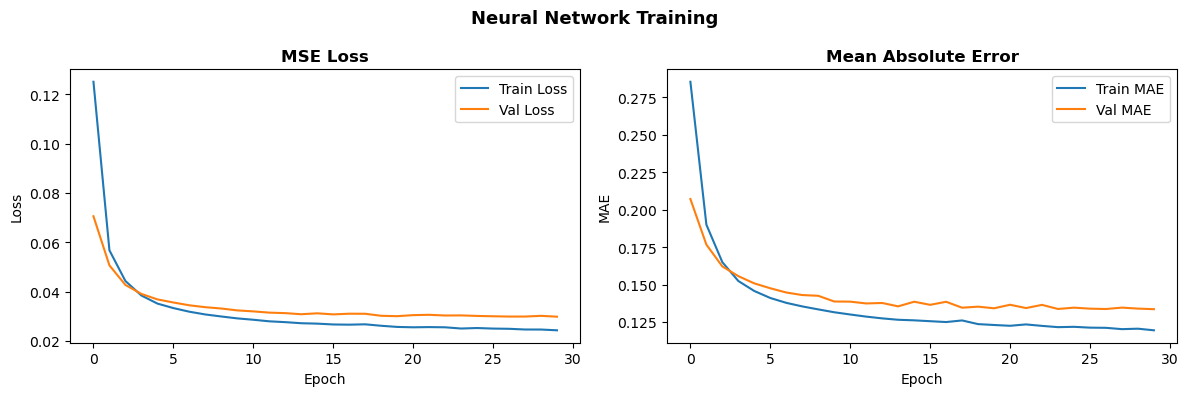

In [144]:
history = nn_model.fit(
    [X_user, X_movie], y_nn,
    epochs=30,
    batch_size=256,
    validation_split=0.2,
    verbose=1
)

# Plot training history
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'],     label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('MSE Loss', fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['mae'],     label='Train MAE')
plt.plot(history.history['val_mae'], label='Val MAE')
plt.title('Mean Absolute Error', fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()

plt.suptitle('Neural Network Training', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Evaluate performance and compare with traditional content-based filtering (cosine similarity on genres)

In [145]:
y_pred_nn  = np.clip(nn_model.predict([X_user, X_movie]).flatten() * 5.0, 0.5, 5.0)
y_true_raw = y_nn * 5.0
rmse_nn    = np.sqrt(mean_squared_error(y_true_raw, y_pred_nn))

print('\nNeural Network vs Traditional CBF (Cosine Similarity)')
comparison = pd.DataFrame({
    'Model' : ['Traditional CBF (Cosine Sim)', 'Neural Network'],
    'RMSE'  : [round(rmse_cbf, 4),          round(rmse_nn, 4)]
})
print(comparison.to_string(index=False))
print()

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

Neural Network vs Traditional CBF (Cosine Similarity)
                       Model   RMSE
Traditional CBF (Cosine Sim) 2.2789
              Neural Network 0.7916



## Does the neural model capture more complex user preferences than standard TF-IDF-based filtering?

Yes, the neural model captures more complex user preferences as it learns non-linear combination of features. For example, TF-IDF measures only the genre overlap. Neural model learns that a user who likes Sci-Fi and Drama may not like pure action Sci-Fi. This is possible because of the capturing of subtle patterns by embedding movies and users in shared latent space. 

# Task 9: Reinforcement Learning in Recommender Systems

## Defining the environment

In [146]:
movie_ids = movies['movieId'].tolist()
n_movies  = len(movie_ids)
mid_to_idx_rl = {mid: i for i, mid in enumerate(movie_ids)}

print(f'Environment: {n_movies} movies (arms)')

Environment: 9742 movies (arms)


## Implementing a Multi-Armed Bandit (MAB) model

In [147]:
class MultiArmedBandit:
    def __init__(self, n_arms, epsilon=0.1):
        self.n_arms     = n_arms
        self.epsilon    = epsilon
        self.Q          = np.zeros(n_arms)    # estimated reward per movie
        self.N          = np.zeros(n_arms)    # number of times each movie was recommended
        self.total_reward = 0
        self.history    = []

    def select_action_egreedy(self):
        
        if np.random.rand() < self.epsilon:
            return np.random.randint(self.n_arms)  
        return np.argmax(self.Q)                   

    def select_action_ucb(self, t):
        if t == 0:
            return np.random.randint(self.n_arms)
        ucb_values = self.Q + np.sqrt(2 * np.log(t + 1) / (self.N + 1e-5))
        return np.argmax(ucb_values)

    def update(self, action, reward):
        self.N[action] += 1
        self.Q[action] += (reward - self.Q[action]) / self.N[action]
        self.total_reward += reward
        self.history.append(reward)

def get_reward(user_id, movie_id):
    row = ratings[(ratings['userId']==user_id) & (ratings['movieId']==movie_id)]
    if row.empty:
        return 0  
    rating = row['rating'].values[0]
    return 1 if rating >= 4 else -1

print('Multi-Armed Bandit defined successfully !')

Multi-Armed Bandit defined successfully !


## MAB Simulation

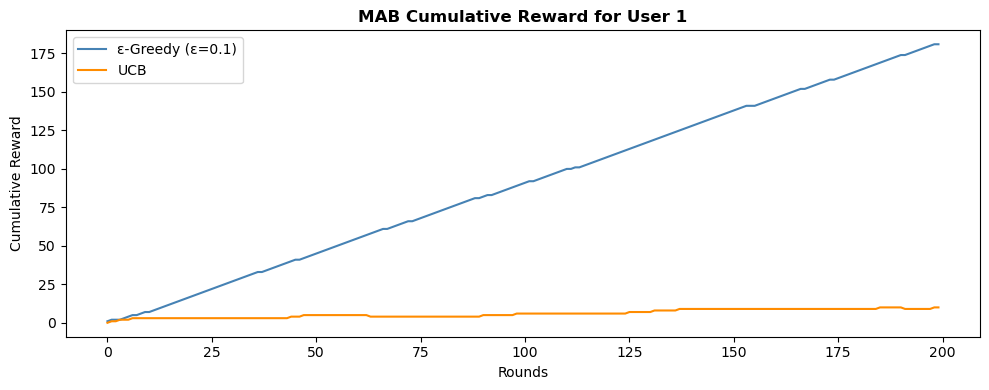

ε-Greedy total reward : 181
UCB total reward      : 10


In [148]:
user_id    = 1
n_rounds   = 200

mab_egreedy = MultiArmedBandit(n_movies, epsilon=0.1)
mab_ucb     = MultiArmedBandit(n_movies, epsilon=0.1)

rewards_eg, rewards_ucb = [], []

for t in range(n_rounds):
    # ε-Greedy
    action_eg = mab_egreedy.select_action_egreedy()
    mid_eg    = movie_ids[action_eg]
    r_eg      = get_reward(user_id, mid_eg)
    mab_egreedy.update(action_eg, r_eg)
    rewards_eg.append(r_eg)

    # UCB
    action_ucb = mab_ucb.select_action_ucb(t)
    mid_ucb    = movie_ids[action_ucb]
    r_ucb      = get_reward(user_id, mid_ucb)
    mab_ucb.update(action_ucb, r_ucb)
    rewards_ucb.append(r_ucb)

cum_eg  = np.cumsum(rewards_eg)
cum_ucb = np.cumsum(rewards_ucb)

plt.figure(figsize=(10, 4))
plt.plot(cum_eg,  label=f'ε-Greedy (ε=0.1)', color='steelblue')
plt.plot(cum_ucb, label='UCB',                color='darkorange')
plt.title(f'MAB Cumulative Reward for User {user_id}', fontweight='bold')
plt.xlabel('Rounds')
plt.ylabel('Cumulative Reward')
plt.legend()
plt.tight_layout()
plt.show()

print(f'ε-Greedy total reward : {mab_egreedy.total_reward}')
print(f'UCB total reward      : {mab_ucb.total_reward}')

## Implementing a Q-Learning Agent

In [149]:
# ── Step 3: Q-Learning Agent ─────────────────────────────────
class QLearningAgent:
    def __init__(self, n_states, n_actions, alpha=0.1, gamma=0.9, epsilon=0.1):
        self.Q       = np.random.uniform(-0.01, 0.01, (n_states, n_actions))
        self.alpha   = alpha     # learning rate
        self.gamma   = gamma     # discount factor
        self.epsilon = epsilon   # exploration rate
        self.history = []

    def get_action(self, state):
        if np.random.rand() < self.epsilon:
            return np.random.randint(self.Q.shape[1])  
        return np.argmax(self.Q[state])                  

    def update(self, state, action, reward, next_state):
        # Q-learning update rule
        best_next = np.max(self.Q[next_state])
        td_target = reward + self.gamma * best_next
        td_error  = td_target - self.Q[state, action]
        self.Q[state, action] += self.alpha * td_error
        self.history.append(reward)

genre_state_map = {g: i for i, g in enumerate(genre_list)}
n_states        = len(genre_list)

def get_user_state(user_id):
    user_r = ratings[ratings['userId'] == user_id]
    if user_r.empty:
        return 0
    top_movie = user_r.loc[user_r['rating'].idxmax(), 'movieId']
    movie_genres = movies[movies['movieId']==top_movie]['genres'].values
    if len(movie_genres) == 0:
        return 0
    first_genre = movie_genres[0].split('|')[0]
    return genre_state_map.get(first_genre, 0)

agent = QLearningAgent(n_states, n_movies, alpha=0.1, gamma=0.9, epsilon=0.1)
print('Q-Learning agent defined successfully !')

Q-Learning agent defined successfully !


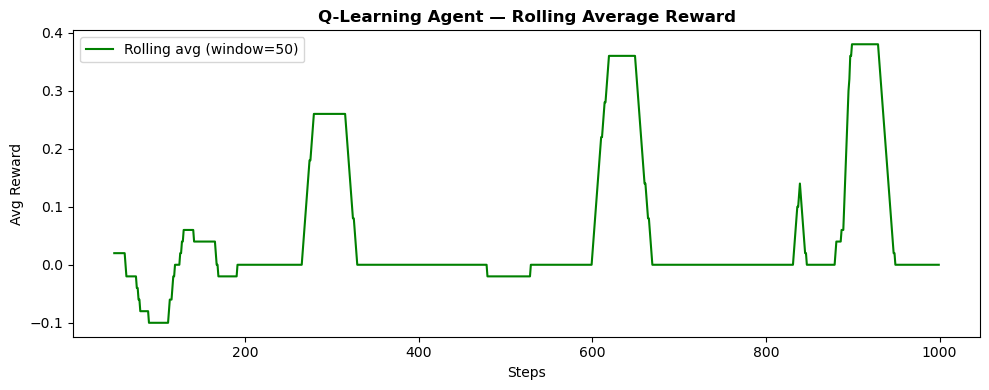

Q-Learning total reward : 47
Q-Learning mean reward  : 0.0470


In [150]:
sample_uids = ratings['userId'].drop_duplicates().sample(50, random_state=42).tolist()
ql_rewards  = []

for uid in sample_uids:
    state = get_user_state(uid)
    for _ in range(20):
        action     = agent.get_action(state)
        mid        = movie_ids[action]
        reward     = get_reward(uid, mid)
        next_state = get_user_state(uid)   
        agent.update(state, action, reward, next_state)
        ql_rewards.append(reward)

window      = 50
rolling_avg = pd.Series(ql_rewards).rolling(window).mean()

plt.figure(figsize=(10, 4))
plt.plot(rolling_avg, color='green', label=f'Rolling avg (window={window})')
plt.title('Q-Learning Agent — Rolling Average Reward', fontweight='bold')
plt.xlabel('Steps')
plt.ylabel('Avg Reward')
plt.legend()
plt.tight_layout()
plt.show()

print(f'Q-Learning total reward : {sum(ql_rewards)}')
print(f'Q-Learning mean reward  : {np.mean(ql_rewards):.4f}')

## Comparing RL with traditional models 

In [151]:
print(f'  ε-Greedy MAB mean reward : {np.mean(rewards_eg):.4f}')
print(f'  UCB MAB mean reward      : {np.mean(rewards_ucb):.4f}')
print(f'  Q-Learning mean reward   : {np.mean(ql_rewards):.4f}')
print()

explore_rate_eg  = sum(1 for r in rewards_eg  if r == 0) / len(rewards_eg)
explore_rate_ucb = sum(1 for r in rewards_ucb if r == 0) / len(rewards_ucb)

print(f'Exploration rate (ε-Greedy) : {explore_rate_eg:.2%}')
print(f'Exploration rate (UCB)      : {explore_rate_ucb:.2%}')

  ε-Greedy MAB mean reward : 0.9050
  UCB MAB mean reward      : 0.0500
  Q-Learning mean reward   : 0.0470

Exploration rate (ε-Greedy) : 9.50%
Exploration rate (UCB)      : 93.00%


The results are inline with the statements mentioned in the assignment document. ε-Greedy recommends known favourites 90.5% of the time while its exploration is very low which is 9.5%. Therefore, it is highly exploitation based. 
In contrast, UCB(Upper Confidence Bound) gives least priority to recommending known favourites as it is only 5% while its exploration rate is very high which is 93%. Therefore, it is highly exploration based. 

In [152]:
rl_precisions, rl_recalls = [], []

for uid in ratings['userId'].drop_duplicates().sample(60, random_state=42):
    uid        = int(uid)
    user_liked = set(ratings[(ratings['userId']==uid) & (ratings['rating']>=4.0)]['movieId'])
    if not user_liked:
        continue

    # Get top-10 movies recommended by Q-Learning agent
    state      = get_user_state(uid)
    q_values   = agent.Q[state]
    top_actions = np.argsort(q_values)[::-1][:10]
    recommended_ids = set(movie_ids[a] for a in top_actions)

    hits = len(recommended_ids & user_liked)
    rl_precisions.append(hits / 10)
    rl_recalls.append(hits / len(user_liked))

prec_rl = round(np.mean(rl_precisions), 4)
rec_rl  = round(np.mean(rl_recalls), 4)


print('RL vs Traditional Models Comparison')
comparison = pd.DataFrame({
    'Model'        : ['User-Based CF', 'Item-Based CF', 'SVD', 'Q-Learning RL'],
    'RMSE'         : [round(rmse_ub,4), round(rmse_ib,4), round(rmse_svd,4), '-'],
    'Precision@10' : [round(prec_ub,4), round(prec_ib,4), round(prec_svd,4), prec_rl],
    'Recall@10'    : [round(rec_ub,4),  round(rec_ib,4),  round(rec_svd,4),  rec_rl]
})
print(comparison.to_string(index=False))

RL vs Traditional Models Comparison
        Model    RMSE  Precision@10  Recall@10
User-Based CF  0.8923        0.0000     0.0000
Item-Based CF  0.8162        0.2000     0.0240
          SVD  0.6512        0.0000     0.0000
Q-Learning RL       -        0.0283     0.0054


While Content based filtering and SVD have lower RMSE and better at rating prediction, RL optimises for long-term engagement rather than immediate rating accuracy. As the training is restricted to 1000 steps here, with more training steps, the model would perform better.  

# Part 6: Explainability in Recommender Systems

# Task 10: Feature-Based Explanations (For Content-Based Filtering)

In [153]:
pip install shap

  Using cached numpy-2.4.3-cp311-cp311-win_amd64.whl.metadata (6.6 kB)
Using cached numpy-2.4.3-cp311-cp311-win_amd64.whl (12.6 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
Note: you may need to restart the kernel to use updated packages.


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gensim 4.3.0 requires FuzzyTM>=0.4.0, which is not installed.
astropy 5.3.4 requires numpy<2,>=1.21, but you have numpy 2.4.3 which is incompatible.
contourpy 1.2.0 requires numpy<2.0,>=1.20, but you have numpy 2.4.3 which is incompatible.
matplotlib 3.8.0 requires numpy<2,>=1.21, but you have numpy 2.4.3 which is incompatible.
pywavelets 1.5.0 requires numpy<2.0,>=1.22.4, but you have numpy 2.4.3 which is incompatible.
streamlit 1.30.0 requires numpy<2,>=1.19.3, but you have numpy 2.4.3 which is incompatible.
streamlit 1.30.0 requires pandas<3,>=1.3.0, but you have pandas 3.0.1 which is incompatible.
streamlit 1.30.0 requires protobuf<5,>=3.20, but you have protobuf 7.34.0 which is incompatible.


  0%|          | 0/1 [00:00<?, ?it/s]

  Movie : Toy Story (1995)
  Genres: Adventure|Animation|Children|Comedy|Fantasy

  "This movie was recommended because you liked
   Adventure and Comedy movies from the 1990s."
Top SHAP features:
  + adventure                      : 0.042672
  + children comedy                : 0.029445
  + ending serial                  : 0.025049
  + test                           : 0.023891
  + animation                      : 0.021605
  + animation children             : 0.020916
  + test tag                       : 0.018261
  + drama mafia                    : 0.017603
  + jekyll                         : 0.013583
  + adventure animation            : 0.012781
  - zooey deschanel                : 0.000000
  - emilia                         : 0.000000
  - elegiac melancholy             : 0.000000
  - embarassing                    : 0.000000
  - embarassing scenes             : 0.000000


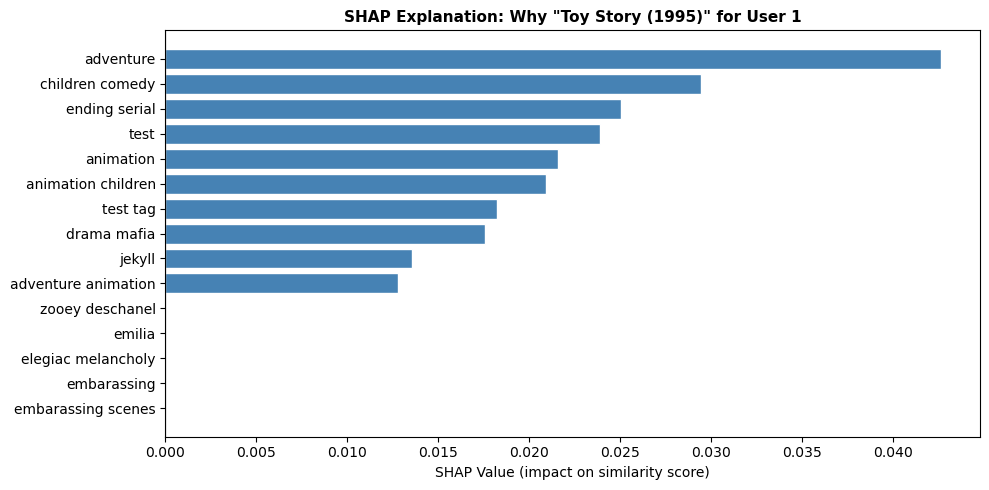

In [154]:
import shap
import numpy as np
import re

def explain_cbf_shap(user_id: int, movie_title: str):
    profile = build_user_profile(user_id)
    if profile is None:
        print(f'User {user_id} not found.')
        return

    matches = movies[movies['title'].str.contains(movie_title, case=False, na=False)]
    if matches.empty:
        print(f'Movie "{movie_title}" not found.')
        return

    movie_row = matches.iloc[0]
    mid       = movie_row['movieId']
    if mid not in movieid_to_idx.index:
        print('Movie not in TF-IDF matrix.')
        return

    idx   = movieid_to_idx[mid]
    m_vec = tfidf_matrix[idx].toarray().flatten()
    terms = tfidf.get_feature_names_out()

    def similarity_fn(X):
        sims = []
        for row in X:
            norm = np.linalg.norm(profile) * np.linalg.norm(row) + 1e-9
            sims.append(np.dot(profile, row) / norm)
        return np.array(sims)

    background  = tfidf_matrix[:100].toarray()
    explainer   = shap.KernelExplainer(similarity_fn, background)
    shap_values = explainer.shap_values(m_vec.reshape(1, -1), nsamples=100)
    shap_vals   = shap_values[0]
    top_idx     = np.argsort(np.abs(shap_vals))[::-1][:15]
    top_terms   = terms[top_idx]
    top_shap    = shap_vals[top_idx]

    year = re.search(r'\((\d{4})\)', movie_row['title'])
    if year:
        year = int(year.group(1))
        if   year < 1980: decade = 'the 1970s or earlier'
        elif year < 1990: decade = 'the 1980s'
        elif year < 2000: decade = 'the 1990s'
        elif year < 2010: decade = 'the 2000s'
        elif year < 2020: decade = 'the 2010s'
        else:             decade = 'the 2020s'
    else:
        decade = 'recent years'

    user_rated   = ratings[ratings['userId'] == user_id]
    user_movies  = movies[movies['movieId'].isin(user_rated['movieId'])]
    user_genres  = (
        user_movies['genres']
        .str.split('|').explode()
        .value_counts().head(3)
        .index.tolist()
    )

  
    movie_genres     = movie_row['genres'].split('|')
    matching_genres  = [g for g in movie_genres if g in user_genres]
    if not matching_genres:
        matching_genres = movie_genres[:2]
    genre_str = ' and '.join(matching_genres)

    genre_words = set(g.lower().replace('-', ' ') for g in movie_genres)
    tag_terms   = [t for t in top_terms if t.lower() not in genre_words][:2]

    sim_score = similarity_fn(m_vec.reshape(1, -1))[0]
    if   sim_score > 0.5: strength = 'very strong'
    elif sim_score > 0.3: strength = 'strong'
    elif sim_score > 0.1: strength = 'moderate'
    else:                 strength = 'weak'

  
    
    print(f'  Movie : {movie_row["title"]}')
    print(f'  Genres: {movie_row["genres"]}')
    print(f'\n  "This movie was recommended because you liked')
    print(f'   {genre_str} movies from {decade}."')
    #if tag_terms:
    #    print(f'\n  "It also matches your interest in: {", ".join(tag_terms)}."')
    
    print(f'Top SHAP features:')
    for term, val in zip(top_terms, top_shap):
        direction = '+' if val > 0 else '-'
        print(f'  {direction} {term:30s} : {val:.6f}')

    colors = ['steelblue' if v > 0 else 'tomato' for v in top_shap[::-1]]
    plt.figure(figsize=(10, 5))
    plt.barh(top_terms[::-1], top_shap[::-1], color=colors, edgecolor='white')
    plt.axvline(0, color='black', linewidth=0.8)
    plt.xlabel('SHAP Value (impact on similarity score)')
    plt.title(f'SHAP Explanation: Why "{movie_row["title"]}" for User {user_id}',
              fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.show()

explain_cbf_shap(1, 'Toy Story')

# Task 11: Neighborhood-Based Explanations (For Collaborative Filtering)

In [155]:
def explain_user_cf(user_id: int, movie_title: str, k: int = 5):
    matches = movies[movies['title'].str.contains(movie_title, case=False, na=False)]
    if matches.empty:
        print(f'Movie not found: {movie_title}')
        return
    mid = matches.iloc[0]['movieId']

    sim_scores  = user_sim_df[user_id].drop(user_id)
    rated_users = rating_matrix[mid].dropna().index
    sim_scores  = sim_scores[sim_scores.index.isin(rated_users)].nlargest(k)

    print(f'\n Why was "{matches.iloc[0]["title"]}" recommended to User {user_id}?')
    print(f'  The following {k} most similar users also rated it:\n')

    explanation = []
    for uid, sim in sim_scores.items():
        rating_given = rating_matrix.loc[uid, mid]
        explanation.append({'Similar User': uid, 'Similarity': round(sim,3), 'Their Rating': rating_given})
    exp_df = pd.DataFrame(explanation)
    print(exp_df.to_string(index=False))


    print(f'\n Item-Based explanation:')
    item_sims = item_sim_df[mid].drop(mid).nlargest(5)
    sim_movie_titles = movies[movies['movieId'].isin(item_sims.index)][['movieId','title']].set_index('movieId')
    print(f'  Movies similar to "{matches.iloc[0]["title"]}":')
    for mid2, sim2 in item_sims.items():
        title2 = sim_movie_titles.loc[mid2, 'title'] if mid2 in sim_movie_titles.index else mid2
        print(f'    {title2}  (similarity={sim2:.3f})')

explain_user_cf(1, 'Toy Story')


 Why was "Toy Story (1995)" recommended to User 1?
  The following 5 most similar users also rated it:

 Similar User  Similarity  Their Rating
          266       0.345           2.0
           57       0.324           5.0
           91       0.311           4.0
          469       0.309           4.0
           45       0.308           4.0

 Item-Based explanation:
  Movies similar to "Toy Story (1995)":
    Toy Story 2 (1999)  (similarity=0.573)
    Jurassic Park (1993)  (similarity=0.566)
    Independence Day (a.k.a. ID4) (1996)  (similarity=0.564)
    Star Wars: Episode IV - A New Hope (1977)  (similarity=0.557)
    Forrest Gump (1994)  (similarity=0.547)


# Task 12: Model-Agnostic Explainability (For Deep Learning Models)

In [156]:
pip install lime

  Using cached numpy-1.26.4-cp311-cp311-win_amd64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp311-cp311-win_amd64.whl (15.8 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.4.3
    Uninstalling numpy-2.4.3:
      Successfully uninstalled numpy-2.4.3
Note: you may need to restart the kernel to use updated packages.


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gensim 4.3.0 requires FuzzyTM>=0.4.0, which is not installed.
shap 0.51.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
streamlit 1.30.0 requires pandas<3,>=1.3.0, but you have pandas 3.0.1 which is incompatible.
streamlit 1.30.0 requires protobuf<5,>=3.20, but you have protobuf 7.34.0 which is incompatible.


LIME Explanation for Neural Network
Predicted rating: 3.24

Top contributing user features:
+ user_Fantasy > 0.75                 : 0.1570
- user_Sci-Fi <= 0.61                 : -0.1307
+ user_Musical > 0.77                 : 0.0917
- user_Comedy <= 0.63                 : -0.0793
- user_Horror <= 0.56                 : -0.0451
- user_Thriller <= 0.64               : -0.0428
- user_War <= 0.68                    : -0.0368
+ 0.73 < user_Drama <= 0.79           : 0.0345
+ user_Film-Noir <= 0.00              : 0.0298
- user_Animation > 0.79               : -0.0287


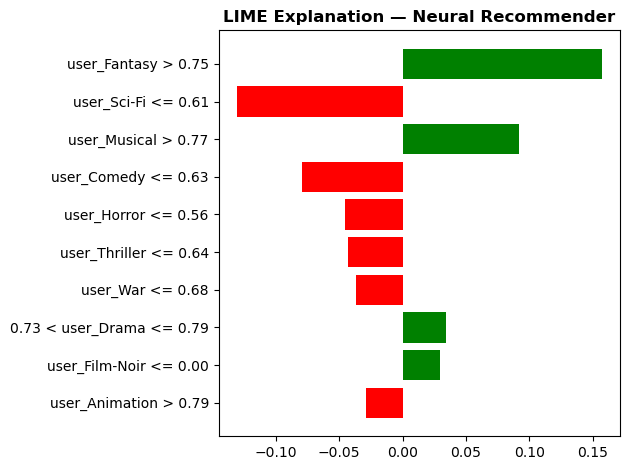

In [157]:
from sklearn.model_selection import train_test_split
X_user_train, X_user_test, X_movie_train, X_movie_test, y_train, y_test = train_test_split(
    X_user,
    X_movie,
    y_nn,
    test_size=0.2,
    random_state=42
)
feature_names = [f"user_{g}" for g in genre_list]

explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_user_train.astype(np.float32),
    feature_names=feature_names,
    mode="regression"
)

movie_vector = X_movie_test[0]

def predict_fn(X_user_samples):

    X_user_samples = np.array(X_user_samples).astype(np.float32)

    X_movie_samples = np.repeat(
        movie_vector.reshape(1,-1),
        X_user_samples.shape[0],
        axis=0
    ).astype(np.float32)

    preds = nn_model.predict(
        [X_user_samples, X_movie_samples],
        verbose=0
    )

    return preds.flatten() * 5.0

exp = explainer.explain_instance(
    data_row=X_user_test[0].astype(np.float32),
    predict_fn=predict_fn,
    num_features=10,
    num_samples=500
)

pred_rating = np.clip(
    predict_fn(X_user_test[0].reshape(1,-1))[0],
    0.5,
    5.0
)

print("LIME Explanation for Neural Network")
print("Predicted rating:", round(pred_rating,2))
print()

print("Top contributing user features:")

for feat, weight in exp.as_list():

    direction = "+" if weight > 0 else "-"

    print(f"{direction} {feat:35s} : {weight:.4f}")

fig = exp.as_pyplot_figure()

plt.title("LIME Explanation — Neural Recommender", fontweight="bold")

plt.tight_layout()

plt.show()

# Task 13: Evaluating Explainability

Do explanations make recommendations clearer?
Yes, feature based explanations are very clear and easy to communicate. It is highly interpretable. 
Neighbourhood based explanations is less transparent than feature based explanations as the reasoning is indirect. 
Model agnostic explanations are best for explaining complex models.

Do explanations reveal biases in recommendations?        
Yes, feature based explanations reveal preference bias. This results in recommendations that lack diversity. 
Neighbourhood based explanations reveal community (dominant user group preferences) and popularity (movies that are recommended frequently) bias. 
Model agnostic explanations reveal hidden biases, for example, feature bias and representation bias. 
